## MNIST met Linear Regression

Bij K-means onthielden we gemiddelde plaatjes.
Nu doen we iets anders:

- We leren per cijfer een formule die zegt hoe waarschijnlijk het is dat een plaatje dat cijfer is.

Dat klinkt spannend, maar het komt neer op:

- pixels krijgen een gewicht

- sommige pixels tellen zwaarder mee dan andere

### Laden MNIST

Je mag je code uit de Kmeans hergebruiken waar van toepassing.

Schrijf een functie die:

- MNIST laadt

- pixelwaarden schaalt naar 0–1

- labels omzet naar gehele getallen

**Vragen:**

Waarom schalen we pixelwaarden?

Hoeveel features heeft één afbeelding?

<br>

**Antwoorden:**

**Waarom schalen we pixelwaarden?** <br>
We schalen de pixelwaardes die normaal een waarde hebben van 0 tot 255 naar een waarde tussen de 0 en de 1:
- Voor het model is het makkelijker om te rekenen met kleine getallen. Hierdoor kan het model beter en sneller leren.
- Als alle waardes zich in een vergelijkbare range bevinden, wordt het model stabieler.
- Zonder scaling zouden pixels met een hoge waarden te veel invloed kunnen hebben op het resultaat.

<br>

**Hoeveel features heeft één afbeelding?** <br>
ELke afbeelding is `28x28` pixels groot. Na reshaping is dat:
```
28 x 28 = 784 pixels
```
Oftewel 1 afbeelding heeft 784 features, want elke pixel vormt 1 feature.


In [1]:
import numpy as np
from keras.datasets import mnist
import matplotlib.pyplot as plt


def load_mnist(scale=True):
    (x_train, y_train), (x_test, y_test) = mnist.load_data()

    x_train = x_train.reshape(-1, 784)
    x_test = x_test.reshape(-1, 784)

    if scale:
        x_train = x_train.astype(np.float32) / 255.0
        x_test = x_test.astype(np.float32) / 255.0

    y_train = y_train.astype(int)
    y_test = y_test.astype(int)

    return x_train, y_train, x_test, y_test


x_train, y_train, x_test, y_test = load_mnist()

### Labels geschikt maken voor regressie

Linear regression werkt met getallen, niet met categorieën.

Waarom is dat?

*Dat is zo, omdat lineaire regressie alleen kan rekenen met getallen die een waarde hebben met een betekenis. In MNIST zijn de getallen (0-9) labels en geen betekenisvolle getallen, want de 9 is bijvoorbeeld niet groter of beter dan 1.*

We doen daarom one-vs-rest:

- eg voor cijfer 3:

- alle 3’en → 1

- alle andere cijfers → 0

Schrijf een functie die:

- één gekozen cijfer omzet naar binaire labels, dus
    - 1 voor het gekozen cijfer
    - 0 voor alle andere cijfers

Vragen:

Waarom kunnen we niet direct 0–9 voorspellen?

Wat betekent een voorspelling van 0.8?

<br>

**Antwoorden:** <br>
**Waarom kunnen we niet direct 0–9 voorspellen?:** <br>
Zoals ik al eerder benoemde, lineaire regressie begrijpt geen categorieen, maar enkel getallen op een schaal.

Als je dan 0 tot 9 direct zou voorspellen, dan gaat regressie foute aannames maken over de volgorde en afstand tussen cijfers.

<br>

**Wat betekent een voorspelling van 0.8?:** <br>
Bij one-vs-rest betekent de output hoe zeker het model ervan is dat het beeld bij het gekozen cijfer hoor. Hoe dichter bij 1, hoe zekerder het model ervan is.


In [ ]:
import numpy as np


def make_binary_labels(labels, digit):
  return (labels == digit).astype(int)


### Lineair model trainen

We leren een gewicht per pixel.

Intuïtief:

- heldere pixels op logische plekken krijgen hoge gewichten

- achtergrond krijgt lage gewichten


Je mag de volgende functie gebruiken:

```python
def train_linear_model(X_train, y_binary):
    model = LinearRegression()
    model.fit(X_train, y_binary)
    return model
```
Kort samengevat: Linearie Regressie berekent exact de optimale waarden voor **intercept** & **coefficients**.

Vragen:

- Wat is X_train hier? <br>
*Je input data. Alle MNIST afbeeldingen, waarbij elke afbeelding is omgezet naar 784 pixels/features.*

- En y_binary? <br>
*De labels voor 1 specifiek cijfer in one-vs-rest 'vorm'. 1 als het cijfer overeenkomt (true) en 0 als het cijfer niet overeenkomt (false).*

- Wat stelt één gewicht voor? <br>
*Een gewicht is het belang van een pixel:*
  - Positief = pixel maakt het model meer zeker dat het dit cijfer is
  - Negatief = pixel maakt het model minder zeker dat het dit cijfer is
  - 0 = pixel is niet belangrijk

- Hoeveel gewichten heeft het model? Tip: kijk naar **model.coef_** <br>
*Het model heeft 784 gewichten, 1 per pixel.*

- Wat is model.intercept_ denk je? <br>
*Dit bepaald het startpunt van de regressie (snijpunt met de y-as). Het is de basiswaarde van de voorspelling als alle pixels 0 zouden zijn.*

In [ ]:
from sklearn.linear_model import LinearRegression

def train_linear_model(X_train, y_binary):
    model = LinearRegression()
    model.fit(X_train, y_binary)
    print(f"coef {model.coef_.shape}")
    return model

train_linear_model(x_train, y_train)

coef (784,)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Model trainen voor 1 cijfer

Laten we eerst het model trainen voor een cijfer.
Stop letterlijk alle 784 (genormaliseerde) pixelwaardes als features in het model
Schrijf code die dat doet

In [ ]:
# loaded mnist is een tuple die komt van

def single_experiment(digit, loaded_mnist):
  x_train, y_train, x_test, y_test = loaded_mnist

  binary_labels = (y_train == digit).astype(int)

  model = LinearRegression()
  model.fit(x_train, binary_labels)

  print(f"coef shape: {model.coef_.shape}")

  return model


### Een cijfer die we getraind hebben voorspellen

Voorspel nu of een test cijfer inderdaad is wat je verwacht.

Maak een functie predict_num met de volgende argumenten:
- model
- image
- echte image waarde

Leg uit waarom we deze 3 nodig hebben?

Je kunt voor het voorspellen de volgende functie gebruiken:
```python
    score = model.predict([image])[0]
```

Waarom is die [0] er? zoek het uit

Score is afhankelijk van het model. In dit geval kun je het lezen als:

- Score > 0 → model denkt: dit is waarschijnlijk een 5

- Score < 0 → model denkt: dit is geen 5

- |score| groot → model is zekerder

In [ ]:
def predict_num(model: LinearRegression, image, digit):
  score = model.predict([image])[0]

  print(f"Score: {score}")
  print(f"Actual label: {digit}")

  return score


model = single_experiment(5, (x_train, y_train, x_test, y_test))
print()

score = predict_num(model, x_test[0], y_test[0])
print()

for i in range(len(y_test)):
  if y_test[i] == 5:
      score = predict_num(model, x_test[i], y_test[i])
      break
  else:
      score = predict_num(model, x_test[i], y_test[i])


coef shape: (784,)

Score: -0.008518323302268982
Actual label: 7

Score: -0.008518323302268982
Actual label: 7
Score: 0.1894395798444748
Actual label: 2
Score: 0.044468313455581665
Actual label: 1
Score: 0.04629707336425781
Actual label: 0
Score: 0.0487520694732666
Actual label: 4
Score: 0.013309091329574585
Actual label: 1
Score: 0.23771533370018005
Actual label: 4
Score: 0.15039990842342377
Actual label: 9
Score: 0.5360020399093628
Actual label: 5


### Experimenteren op een echt getal

Train het nu op bijvoorbeeld getal 5.

Maak nu code waarbij we een random getal uit de database halen en deze classificeren. Je mag de volgende code gebruiken om het getal te tonen:

```python
plt.imshow(random_image.reshape(28, 28), cmap="gray")
plt.title(f"Echte label: {true_label}")
plt.axis("off")
plt.show()
```


### Modellen trainen voor alle cijfers

We trainen 10 aparte modellen:

- één voor 0

- één voor 1

- etc...

Schrijf een functie die:

- voor elk cijfer een model traint

- alle modellen opslaat in een datastructuur

In [ ]:
models = {}

def train_linear_model(x_train, y_train, digit):
    binary_labels = (y_train == digit).astype(int)
    model = LinearRegression()
    model.fit(x_train, binary_labels)
    return model

for digit in range(10):
    models[digit] = train_linear_model(x_train, y_train, digit)

In [ ]:
def predict_number(models, image):
    scores = {}
    for digit, model in models.items():
        score = model.predict([image])[0]
        scores[digit] = score
        print(f"Digit: {digit}, Score: {score}")
    return scores

### Voorspellen

Een nieuw plaatje:

- gaat door alle 10 modellen

- elk model geeft een score

- hoogste score wint

Schrijf een functie **predict_case** die:

- voor elk testplaatje voorspelt welk cijfer het is

- gebruik **model.predict([image])**

Vragen:

Wat betekent een hoge score?

Waarom kiezen we de hoogste score?

Digit: 0, Score: 0.1171911433339119
Digit: 1, Score: 0.3057154417037964
Digit: 2, Score: 0.32228976488113403
Digit: 3, Score: 0.11926737427711487
Digit: 4, Score: -0.02686084806919098
Digit: 5, Score: 0.07634879648685455
Digit: 6, Score: -0.09867426753044128
Digit: 7, Score: -0.023657649755477905
Digit: 8, Score: 0.33935150504112244
Digit: 9, Score: -0.1309707760810852


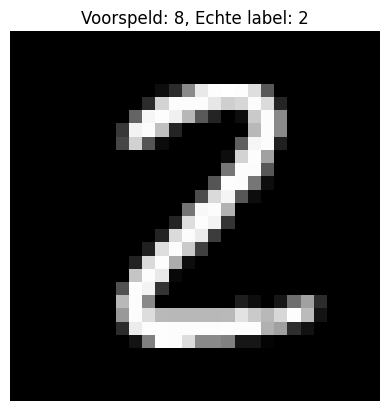

In [ ]:
random_index = np.random.randint(0, len(y_test)-1)
random_image = x_test[random_index]
true_label = y_test[random_index]

scores = predict_number(models, random_image)
predicted_label = max(scores, key=scores.get)

plt.imshow(random_image.reshape(28, 28), cmap="gray")
plt.title(f"Voorspeld: {predicted_label}, Echte label: {true_label}")
plt.axis("off")
plt.show()

### Gebruik nu je eigen features

Gebruik een functie uit de vorige opdrachten om je eigen features te gebruiken voor linear regression.


def extract_features(img):
    features = []
    features.append(img.mean())                      # gemiddelde intensiteit
    features.append((img > 0.5).sum())               # aantal "actieve" pixels
    ...
    ....
    return features


In [ ]:
# Feature extraction function - reusing concepts from the decision tree assignment

def extract_custom_features(image):   
    features = []
    
    # 1. Percentage of dark pixels
    dark_pixels = np.sum(image == 0)
    percentage_dark = (dark_pixels / image.size) * 100
    features.append(percentage_dark)
    
    # 2. Top-bottom ratio
    top = image[:image.shape[0]//2, :]
    bottom = image[image.shape[0]//2:, :]
    top_sum = np.sum(top)
    bottom_sum = np.sum(bottom)
    tb_ratio = top_sum / (bottom_sum + 1) 
    features.append(tb_ratio)
    
    # 3. Left-right ratio
    left = image[:, :image.shape[1]//2]
    right = image[:, image.shape[1]//2:]
    left_sum = np.sum(left)
    right_sum = np.sum(right)
    lr_ratio = left_sum / (right_sum + 1) 
    features.append(lr_ratio)
    
    # 4 & 5. Height and width
    rows = np.any(image != 0, axis=1)
    cols = np.any(image != 0, axis=0)
    row_indices = np.where(rows)[0]
    col_indices = np.where(cols)[0]
    
    if len(row_indices) > 0:
        height = row_indices[-1] - row_indices[0] + 1
    else:
        height = 0
    
    if len(col_indices) > 0:
        width = col_indices[-1] - col_indices[0] + 1
    else:
        width = 0
    
    features.append(height)
    features.append(width)
    
    # 6. Symmetry (vertical symmetry)
    left_half = image[:, :image.shape[1]//2]
    right_half = np.fliplr(image[:, image.shape[1]//2:])
    matches = np.sum(left_half == right_half)
    symmetry = (matches / left_half.size) * 100
    features.append(symmetry)
    
    # 7 & 8. Average and standard deviation
    average = np.mean(image)
    stdev = np.std(image)
    features.append(average)
    features.append(stdev)
    
    return np.array(features)


# Extract features for training and test data
print("Extracting custom features from MNIST data...")
X_train_features = np.array([extract_custom_features(img.reshape(28, 28)) for img in x_train])
X_test_features = np.array([extract_custom_features(img.reshape(28, 28)) for img in x_test])

print(f"Training features shape: {X_train_features.shape}")
print(f"Test features shape: {X_test_features.shape}")
print(f"Number of features per image: {X_train_features.shape[1]}")
print()

# Train models for each digit using custom features
print("Training linear regression models with custom features...")
models_custom = {}

for digit in range(10):
    y_binary = (y_train == digit).astype(int)
    model = LinearRegression()
    model.fit(X_train_features, y_binary)
    models_custom[digit] = model
    print(f"Trained model for digit {digit}")

print()

# Test the model with custom features
def predict_with_custom_features(models, test_image_features):
    """Predict the digit using custom features"""
    scores = {}
    for digit, model in models.items():
        score = model.predict([test_image_features])[0]
        scores[digit] = score
    
    predicted_digit = max(scores, key=scores.get)
    return predicted_digit, scores


# Evaluate on test set
correct = 0
total = 0

print("\nTesting predictions on random test samples:")
for i in range(10):
    random_idx = np.random.randint(0, len(y_test))
    test_features = X_test_features[random_idx]
    true_label = y_test[random_idx]
    
    predicted, scores = predict_with_custom_features(models_custom, test_features)
    
    print(f"Predicted: {predicted}, Actual: {true_label}")
    
    if predicted == true_label:
        correct += 1
    total += 1

print(f"\nAccuracy on sample: {correct}/{total} = {100*correct/total:.1f}%")

# Full accuracy calculation
print("\nCalculating full accuracy on test set...")
predictions = []
for i in range(len(X_test_features)):
    predicted, _ = predict_with_custom_features(models_custom, X_test_features[i])
    predictions.append(predicted)
    if (i + 1) % 1000 == 0:
        print(f"Processed {i+1}/{len(X_test_features)} test samples")

predictions = np.array(predictions)
full_accuracy = np.mean(predictions == y_test)
print(f"\nFull accuracy on test set: {100*full_accuracy:.2f}%")

# Comparison with original 784-feature model
print(f"\nComparison:")
print(f"Custom features (8 features): {100*full_accuracy:.2f}% accuracy")
print(f"Note: Using only {X_train_features.shape[1]} features instead of 784 pixels!")


Extracting custom features from MNIST data...
Training features shape: (60000, 8)
Test features shape: (10000, 8)
Number of features per image: 8

Training linear regression models with custom features...
Trained model for digit 0
Trained model for digit 1
Trained model for digit 2
Trained model for digit 3
Trained model for digit 4
Trained model for digit 5
Trained model for digit 6
Trained model for digit 7
Trained model for digit 8
Trained model for digit 9


Testing predictions on random test samples:
Predicted: 7, Actual: 7
Predicted: 1, Actual: 1
Predicted: 3, Actual: 3
Predicted: 4, Actual: 9
Predicted: 8, Actual: 5
Predicted: 7, Actual: 3
Predicted: 7, Actual: 9
Predicted: 7, Actual: 5
Predicted: 7, Actual: 5
Predicted: 0, Actual: 0

Accuracy on sample: 4/10 = 40.0%

Calculating full accuracy on test set...
Processed 1000/10000 test samples
Processed 2000/10000 test samples
Processed 3000/10000 test samples
Processed 4000/10000 test samples
Processed 5000/10000 test samples
Pro

## Rapporteer:




De gemaakte opdrachten en de discussie/feedbackmoeten worden uitgewerkt en op CodeGrade geplaatst onder **P6 Linear Regression**